
This notebook demonstrates the **complete research workflow** for evaluating the Dempster-Shafer belief-based intent clarification system across multiple datasets (e.g., `banking77`, `clinc150`, `snips`, `atis`).

Select the dataset in the **Setup and Configuration** section; all steps, paths, and sample counts update accordingly.

### Phase 1: Configure Optimal DS Agent (One-Time Setup)

**STEP 0**: Vanilla Baseline (Pure LogisticRegression + E5-BERT)
- Train classifier on the selected dataset
- Evaluate without hierarchy or DS reasoning
- Establish baseline performance metrics

**STEP 1**: Extract Belief Values
- Initialize DS system with hierarchy
- Compute beliefs for all intents using DEFAULT thresholds
- Extract per-intent belief distributions for optimization
- Output: `{dataset}_beliefs.csv` (used for STEP 2)

**STEP 2**: Compute Optimal Thresholds
- Analyze belief distributions from STEP 1
- Find optimal threshold per intent using ancestor-aware ground truth
- Test multiple threshold values (0.0-1.0) to maximize F1
- Output: `{dataset}_optimal_thresholds.json` (used for STEP 3)

### Phase 2: Deploy DS Agent with Optimal Configuration

**STEP 3**: DS Evaluation WITH Optimal Thresholds
- Initialize DS system with optimal thresholds from STEP 2
- LLM-based user simulation for clarifications
- Measure: Accuracy, clarification rate, belief progression
- Output: `{dataset}_predictions.csv` (used for STEP 5)

**STEP 5**: Select User Study Queries
- Analyze STEP 3 results to identify challenging queries
- Prioritize by: low confidence, high interactions, incorrect predictions
- Select top N queries for real human validation
- Output: `selected_queries_for_user_study.csv` (used for STEP 6)

**STEP 6**: Real User Study (Streamlit Interactive Interface)
- Launch Streamlit app with selected challenging queries
- Real human participants replace LLM agent
- Track belief progression and collect human responses
- Validate predictions with actual user behavior

### Phase 3: Analysis & Reporting

**STEP 7**: Comparison Report
- Compare: Vanilla baseline vs DS with optimal thresholds vs Real users
- Analyze improvements in accuracy, clarification effectiveness
- Generate visualizations and summary metrics

---

## Key Differences from Baseline

| Aspect | Vanilla Baseline | DS with Optimal Thresholds | Real User Study |
|--------|------------------|---------------------------|-----------------|
| **What** | LogisticRegression + BERT | DS hierarchy + clarifications | Real humans replace LLM |
| **Queries** | All test queries (dataset-dependent) | Same test set | Selected challenging queries |
| **Clarifications** | None | LLM-simulated | Real human users |
| **Focus** | Baseline metrics | Optimized performance | Validation with humans |

---

**Demo Mode**: This notebook uses small sample sizes for quick testing. Set `QUICK_DEMO = False` for full evaluation.

## Setup and Configuration

Initialize paths, load dependencies, and configure the workflow.

In [1]:
from ipywidgets import Dropdown

dataset_selector = Dropdown(
    options=["banking77", "clinc150", "snips", "atis"],
    value="banking77",
    description="Dataset:",
)

dataset_selector

Dropdown(description='Dataset:', options=('banking77', 'clinc150', 'snips', 'atis'), value='banking77')

In [2]:
import sys
from pathlib import Path
import os

# Add project root to path
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import logging
from datasets import load_dataset
import pandas as pd
import json

from src.data.data_loader import DataLoader

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Configuration
QUICK_DEMO = False  # Set to False for full evaluation

DATASET = dataset_selector.value if "dataset_selector" in globals() else "banking77"

# NOTE: DataLoader handles CLINC150 OOS filtering (intent != "oos"), matching SVM_DS_clinc150.
BASE_DIR = project_root
EXPERIMENTS_DIR = BASE_DIR / "experiments" / DATASET
RESULTS_DIR = BASE_DIR / "results" / DATASET / "workflow_demo"
CONFIG_DIR = BASE_DIR / "config"
USER_STUDY_DIR = BASE_DIR / "outputs" / "user_study" / "workflow_demo"

# Sample sizes
if QUICK_DEMO:
    TRAIN_SAMPLES = None  # Use full training set even in demo
    EVAL_SAMPLES = 50     # Quick evaluation
    LLM_SAMPLES = 100     # Quick LLM simulation
    HUMAN_STUDY_SAMPLES = 30  # Queries for human study
else:
    TRAIN_SAMPLES = None
    EVAL_SAMPLES = None   # Full test set
    LLM_SAMPLES = None    # Full test set
    HUMAN_STUDY_SAMPLES = 100

# Create directories
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
USER_STUDY_DIR.mkdir(parents=True, exist_ok=True)

# Dynamic dataset size for printing
data_loader = DataLoader(DATASET)
data_loader.load()
eval_total = len(data_loader.get_split_data("test")[0])

print(f"   Configuration complete")
print(f"   Mode: {'QUICK DEMO' if QUICK_DEMO else 'FULL EVALUATION'}")
print(f"   Dataset: {DATASET}")
print(f"   Evaluation samples: {EVAL_SAMPLES if EVAL_SAMPLES else f'All ({eval_total})'}")
print(f"   LLM simulation samples: {LLM_SAMPLES if LLM_SAMPLES else f'All ({eval_total})'}")
print(f"   Human study queries: {HUMAN_STUDY_SAMPLES}")

2026-02-17 12:15:37,775 - INFO - Loading dataset: clinc150
2026-02-17 12:15:41,245 - INFO - Loaded clinc150: 150 intents


   Configuration complete
   Mode: FULL EVALUATION
   Dataset: clinc150
   Evaluation samples: All (4500)
   LLM simulation samples: All (4500)
   Human study queries: 100


## STEP 0: Vanilla Baseline (Pure LogisticRegression + BERT)

Evaluate pure Logistic Regression + E5-BERT embeddings (no hierarchy, no DS reasoning).

**What it does:**
- Trains classifier on Banking77
- Evaluates on test set (all 3,080 samples)
- Computes: Accuracy, F1, Precision, Recall, Confidence stats
- Establishes baseline for comparison with DS system

**Output:** `vanilla_metrics.json`, `vanilla_predictions.csv`

In [3]:
# Force reload modules to get latest code changes
import sys
import importlib
import importlib.util
from pathlib import Path

if 'src.models.embeddings' in sys.modules:
    importlib.reload(sys.modules['src.models.embeddings'])
if 'scripts.training.train' in sys.modules:
    importlib.reload(sys.modules['scripts.training.train'])

from scripts.training.train import train_model

eval_module_path = Path(BASE_DIR) / "scripts" / "evaluation" / "evaluate_vanilla_baseline.py"
spec = importlib.util.spec_from_file_location("evaluate_vanilla_baseline", eval_module_path)
evb = importlib.util.module_from_spec(spec)
spec.loader.exec_module(evb)
evaluate_vanilla_baseline = evb.evaluate_vanilla_baseline

import json

print("="*60)
print("STEP 0: VANILLA BASELINE EVALUATION")
print("="*60)

# Step 0.1: Train model
print("\n[0.1] Training vanilla baseline model...")
train_results = train_model(
    dataset=DATASET,
    classifier_type='logistic',
    embedding_model='intfloat/e5-base',
    output_dir=EXPERIMENTS_DIR,
    experiment_name=f"{DATASET}_logistic",
    hierarchy_file=None,
    intents_file=None,
    max_iter=1000,
    batch_size=64,
    train_samples=TRAIN_SAMPLES,
    eval_samples=None
)

# Extract objects from training results
classifier = train_results['classifier']
embedder = train_results['embedder']
data_loader = train_results['data_loader']

# Step 0.2: Evaluate on test set
print("\n[0.2] Evaluating on test set...")
vanilla_output_dir = RESULTS_DIR / "vanilla"
vanilla_output_dir.mkdir(parents=True, exist_ok=True)

metrics = evaluate_vanilla_baseline(
    classifier=classifier,
    embedder=embedder,
    intent_names=data_loader.intent_names,
    dataset_name=DATASET,
    num_samples=EVAL_SAMPLES,
    batch_size=64,
    output_dir=vanilla_output_dir
)

print("\n✅ STEP 0 Complete!")
print(f"   Accuracy: {metrics['accuracy']:.4f}")
print(f"   F1 (macro): {metrics['f1_macro']:.4f}")
print(f"   Saved to: {vanilla_output_dir}")

2026-02-17 12:15:54,615 - INFO - Starting training for clinc150
2026-02-17 12:15:54,615 - INFO - Classifier: logistic
2026-02-17 12:15:54,616 - INFO - Embedding model: intfloat/e5-base
2026-02-17 12:15:54,616 - INFO - Experiment name: clinc150_logistic
2026-02-17 12:15:54,616 - INFO - Loading dataset...
2026-02-17 12:15:54,617 - INFO - Loading dataset: clinc150


STEP 0: VANILLA BASELINE EVALUATION

[0.1] Training vanilla baseline model...


2026-02-17 12:15:56,295 - INFO - Loaded clinc150: 150 intents
2026-02-17 12:15:56,517 - INFO - Training samples: 15000
2026-02-17 12:15:56,518 - INFO - No hierarchy provided. Training vanilla baseline with intent names (STRING labels)...
2026-02-17 12:15:56,518 - INFO - Initializing sentence embedder...
2026-02-17 12:15:56,523 - INFO - Use pytorch device_name: cuda
2026-02-17 12:15:56,523 - INFO - Load pretrained SentenceTransformer: intfloat/e5-base
2026-02-17 12:15:58,050 - INFO - Loaded embedding model: intfloat/e5-base
2026-02-17 12:15:58,050 - INFO - Generating embeddings for training data...


Batches:   0%|          | 0/235 [00:00<?, ?it/s]

2026-02-17 12:15:59,907 - INFO - Skipping intent embeddings (vanilla baseline)
2026-02-17 12:15:59,908 - INFO - Training classifier...
2026-02-17 12:15:59,908 - INFO - Initialized logistic classifier
2026-02-17 12:15:59,908 - INFO - Training logistic classifier on 15000 samples
2026-02-17 12:15:59,908 - INFO - Training with label type: <class 'str'>
2026-02-17 12:16:05,906 - INFO - Training completed
2026-02-17 12:16:05,917 - INFO - Saving model to /home/kudzai/projects/DS_Project/experiments/clinc150/clinc150_logistic_model.pkl
2026-02-17 12:16:05,918 - INFO - Model saved to /home/kudzai/projects/DS_Project/experiments/clinc150/clinc150_logistic_model.pkl
2026-02-17 12:16:05,920 - INFO - Saving embedder to /home/kudzai/projects/DS_Project/experiments/clinc150/clinc150_embedder.json
2026-02-17 12:16:05,927 - INFO - Saved embedder config to /home/kudzai/projects/DS_Project/experiments/clinc150/clinc150_embedder.json
2026-02-17 12:16:05,927 - INFO - Evaluating on test set...
2026-02-17 1


[0.2] Evaluating on test set...


2026-02-17 12:16:08,336 - INFO - Loaded clinc150: 150 intents
2026-02-17 12:16:08,416 - INFO - Evaluating on 4500 test samples...
2026-02-17 12:16:08,416 - INFO - Encoding test texts...


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

2026-02-17 12:16:08,941 - INFO - Making predictions...
2026-02-17 12:16:08,968 - INFO - Predictions type: <class 'numpy.str_'>, sample: translate
2026-02-17 12:16:08,969 - INFO - Test labels type: <class 'str'>, sample: translate
2026-02-17 12:16:08,985 - INFO - Saved predictions to /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/vanilla/clinc150_vanilla_predictions.csv



✅ STEP 0 Complete!
   Accuracy: 0.9464
   F1 (macro): 0.9464
   Saved to: /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/vanilla


## STEP 1: Extract Belief Values (DS Baseline, Default Thresholds)

Extract belief distributions from DS system using DEFAULT thresholds.

**What it does:**
- Initialize DS system with DEFAULT confidence thresholds (Leaf: 0.3, Parent: 0.5, Root: 0.7)
- For each query: `compute_mass_function()` → `compute_belief()` for all intents
- Extract per-intent belief scores (no clarifications triggered at this stage)
- Collects belief data to prepare for optimal threshold computation

**Why default thresholds?**
- Gives us raw belief distributions independent of optimization
- STEP 2 will analyze these beliefs to find better per-intent thresholds
- Ensures we're optimizing based on actual belief values, not classifier confidence

**Output:** `banking77_beliefs.csv` (per-intent beliefs for all 3,080 test queries)

In [4]:
# STEP 1: Belief Extraction
import importlib
import scripts.ds_preparation.extract_beliefs
importlib.reload(scripts.ds_preparation.extract_beliefs)
from scripts.ds_preparation.extract_beliefs import extract_beliefs_from_data

from src.models.embeddings import IntentEmbeddings
from src.models.ds_mass_function import DSMassFunction
from config.hierarchy_loader import load_hierarchy_from_json, load_hierarchical_intents_from_json
import pandas as pd

print("="*60)
print("STEP 1: BELIEF EXTRACTION")
print("="*60)

# Load configuration files
config_file = CONFIG_DIR / "hierarchies" / f"{DATASET}_hierarchy.json"
intents_file = CONFIG_DIR / "hierarchies" / f"{DATASET}_intents.json"

print("\nLoading hierarchy and intents...")
hierarchy = load_hierarchy_from_json(str(config_file))
hierarchical_intents = load_hierarchical_intents_from_json(str(intents_file))

# Create intent embeddings
print("Creating intent embeddings...")
intent_embeddings = IntentEmbeddings(hierarchical_intents, embedder=embedder)

# Initialize DS Mass Function (WITHOUT thresholds for belief extraction)
print("Initializing DS Mass Function...")
ds_calculator = DSMassFunction(
    intent_embeddings=intent_embeddings.get_all_embeddings(),
    hierarchy=hierarchy,
    classifier=classifier,
    custom_thresholds=None,  # No thresholds for belief extraction
    enable_belief_tracking=False  # Disable tracking for efficiency
)

# Extract beliefs
print("\nExtracting belief values (no clarifications)...")
results = extract_beliefs_from_data(
    data_loader=data_loader,
    ds_calculator=ds_calculator,
    dataset_name=DATASET,
    split='test',
    num_samples=EVAL_SAMPLES,
    n_chunks=4,
    output_dir=RESULTS_DIR
)

# Save results
print("\nSaving results...")
beliefs_df = pd.DataFrame(results)
beliefs_file = RESULTS_DIR / f"{DATASET}_beliefs.csv"
beliefs_df.to_csv(beliefs_file, index=False)

print(f"\n✅ STEP 1 Complete!")
print(f"   Total samples: {len(beliefs_df)}")
print(f"   Number of intents: {len(beliefs_df.columns) - 2}")
print(f"   Saved to: {beliefs_file}")


2026-02-17 12:16:16,200 - INFO - Loaded hierarchy from /home/kudzai/projects/DS_Project/config/hierarchies/clinc150_hierarchy.json
2026-02-17 12:16:16,200 - INFO - Loaded hierarchical intents from /home/kudzai/projects/DS_Project/config/hierarchies/clinc150_intents.json


STEP 1: BELIEF EXTRACTION

Loading hierarchy and intents...
Creating intent embeddings...


2026-02-17 12:16:16,678 - INFO - Computed embeddings for 160 intents
2026-02-17 12:16:16,679 - INFO - Use pytorch device_name: cuda
2026-02-17 12:16:16,680 - INFO - Load pretrained SentenceTransformer: intfloat/e5-base


Initializing DS Mass Function...


2026-02-17 12:16:18,158 - INFO - Loaded embedding model: intfloat/e5-base
2026-02-17 12:16:18,158 - INFO - Loading test data...
2026-02-17 12:16:18,159 - INFO - Processing all 5500 samples
2026-02-17 12:16:18,233 - INFO - 
Processing chunk 1/4 (1125 samples)



Extracting belief values (no clarifications)...


Chunk 1: 100%|██████████| 1125/1125 [00:05<00:00, 203.84it/s]
2026-02-17 12:16:23,899 - INFO - Saved chunk 1 to /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/clinc150_beliefs_chunk_1.csv
2026-02-17 12:16:23,899 - INFO - 
Processing chunk 2/4 (1125 samples)
Chunk 2: 100%|██████████| 1125/1125 [00:05<00:00, 200.38it/s]
2026-02-17 12:16:29,662 - INFO - Saved chunk 2 to /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/clinc150_beliefs_chunk_2.csv
2026-02-17 12:16:29,663 - INFO - 
Processing chunk 3/4 (1125 samples)
Chunk 3: 100%|██████████| 1125/1125 [00:05<00:00, 199.82it/s]
2026-02-17 12:16:35,449 - INFO - Saved chunk 3 to /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/clinc150_beliefs_chunk_3.csv
2026-02-17 12:16:35,449 - INFO - 
Processing chunk 4/4 (1125 samples)
Chunk 4: 100%|██████████| 1125/1125 [00:05<00:00, 205.94it/s]
2026-02-17 12:16:41,059 - INFO - Saved chunk 4 to /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo


Saving results...

✅ STEP 1 Complete!
   Total samples: 4500
   Number of intents: 160
   Saved to: /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/clinc150_beliefs.csv


## STEP 2: Threshold Computation

Analyze belief distributions and compute optimal thresholds per intent.

**What it does:**
- Analyze beliefs.csv
- Find threshold that maximizes F1 for each intent
- Balance precision and recall

**Output:** `optimal_thresholds.json`

In [5]:
# STEP 2: Threshold Computation
from scripts.ds_preparation.compute_thresholds import compute_optimal_thresholds, add_ancestor_labels
import json

print("="*60)
print("STEP 2: THRESHOLD COMPUTATION")
print("="*60)

# Load beliefs DataFrame (already loaded from STEP 1)
print(f"\nLoaded beliefs with {len(beliefs_df)} samples")

# Add ancestor-aware ground truth labels
print("Adding ancestor-aware ground truth labels...")
beliefs_df_with_labels = add_ancestor_labels(beliefs_df, hierarchy)

# Identify intent columns (those without 'is_correct_' prefix)
intent_columns = [
    col for col in beliefs_df_with_labels.columns
    if not col.startswith('is_correct_') and col not in ['query', 'true_intent']
]
print(f"Found {len(intent_columns)} intent columns")

# Compute optimal thresholds
print("Computing optimal thresholds...")
optimal_results = compute_optimal_thresholds(
    df=beliefs_df_with_labels,
    intent_columns=intent_columns
)

# Save results
thresholds_file = RESULTS_DIR / f"{DATASET}_optimal_thresholds.json"
with open(thresholds_file, 'w') as f:
    json.dump(optimal_results, f, indent=4)

print(f"\n✅ STEP 2 Complete!")
print(f"   Number of intents: {len(optimal_results)}")
print(f"   Saved to: {thresholds_file}")


2026-02-17 12:16:49,385 - INFO - Computing optimal thresholds for 160 intents...


STEP 2: THRESHOLD COMPUTATION

Loaded beliefs with 4500 samples
Adding ancestor-aware ground truth labels...
Found 160 intent columns
Computing optimal thresholds...


Processing intents: 100%|██████████| 160/160 [00:10<00:00, 15.37it/s]


✅ STEP 2 Complete!
   Number of intents: 160
   Saved to: /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/clinc150_optimal_thresholds.json


## STEP 3: DS Evaluation WITH Optimal Thresholds

Evaluate DS system using optimal thresholds computed in STEP 2.

**What it does:**
- Load optimal thresholds from STEP 2 (`banking77_optimal_thresholds.json`)
- Initialize DS system with these custom thresholds (NOT default)
- LLM-based user simulation (CustomerAgent) provides clarifications
- For each query: clarify → combine masses → evaluate hierarchy
- Measure: Accuracy, F1, average clarifications, belief progression

**Key difference from STEP 1:**
- STEP 1 used default thresholds → many clarifications needed
- STEP 3 uses optimal thresholds → selective, targeted clarifications

**Output:** `ds_predictions.csv` with full interaction logs and belief progression

In [ ]:
from src.agents.customer_agent import CustomerAgent
from config.threshold_loader import load_thresholds_from_json
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import json

print("="*60)
print("STEP 3: DS EVALUATION WITH OPTIMAL THRESHOLDS")
print("="*60)

# Toggle belief logging for explainability analysis (STEP 9)
TRACK_BELIEF_LOGS = True

# Initialize LLM-based customer agent
print("\nInitializing LLM-based customer agent...")
customer_agent = CustomerAgent(rate_limit_delay=0.1)  # 0.1s for faster testing

# Get test data
test_texts, test_labels, _ = data_loader.get_split_data('test')

# Show sample data
sample_data = [{'text': test_texts[i], 'label': test_labels[i]} for i in range(min(10, len(test_texts)))]
print(f"\nSample of test data (first 10 samples):")
print(sample_data)

# Load optimal thresholds using the utility function
print(f"\nLoading optimal thresholds from: {thresholds_file}")
optimal_thresholds = load_thresholds_from_json(str(thresholds_file))
print(f"Loaded {len(optimal_thresholds)} custom thresholds")
print(f"Sample thresholds: {list(optimal_thresholds.items())[:5]}")

# Create ds_calculator WITH optimal thresholds
ds_calculator = DSMassFunction(
    intent_embeddings=intent_embeddings.get_all_embeddings(),
    hierarchy=hierarchy,
    classifier=classifier,
    custom_thresholds=optimal_thresholds,  # Use optimal thresholds from STEP 2 (as dict!)
    enable_belief_tracking=TRACK_BELIEF_LOGS
)
ds_calculator.customer_agent_callback = customer_agent

# Prepare output locations
output_dir = RESULTS_DIR / "ds_evaluation"
output_dir.mkdir(parents=True, exist_ok=True)

belief_logs_dir = output_dir / "belief_logs"
if TRACK_BELIEF_LOGS:
    belief_logs_dir.mkdir(parents=True, exist_ok=True)

# Evaluate with LLM simulation
print("\nEvaluating DS with optimal thresholds (LLM-based user simulation)...")
results = []
interaction_count = 0

for idx, (text, true_intent) in enumerate(zip(test_texts, test_labels)):
    # Reset conversation
    ds_calculator.conversation_history = []
    ds_calculator.clear_belief_history()
    
    # Compute initial mass and get prediction
    initial_mass = ds_calculator.compute_mass_function(text)
    DS_prediction = ds_calculator.evaluate_with_clarifications(initial_mass)
    
    # Extract prediction
    if DS_prediction:
        pred_intent, confidence = DS_prediction
    else:
        pred_intent, confidence = "unknown", 0.0
    
    # Store result
    result = {
        'query': text,
        'true_intent': true_intent,
        'predicted_intent': pred_intent,
        'confidence': confidence,
        'interaction': '\n'.join(ds_calculator.conversation_history)
    }
    results.append(result)

    # Save belief log for explainability analysis (query_1_belief_log.json, ...)
    if TRACK_BELIEF_LOGS:
        belief_log_file = belief_logs_dir / f"query_{idx + 1}_belief_log.json"
        ds_calculator.save_belief_log(str(belief_log_file))
    
    # Print conversation
    if ds_calculator.conversation_history:
        interaction_count += 1
        print(f"\n--- Interaction {interaction_count} ---")
        print(f"Query: {text}")
        print(f"True intent: {true_intent}")
        print(f"Predicted: {pred_intent}")
        for turn in ds_calculator.conversation_history:
            print(turn)
    
    # Progress indicator
    if (idx + 1) % 100 == 0:
        print(f"Processed {idx + 1}/{len(test_texts)} samples...")

# Save results to CSV
results_df = pd.DataFrame(results)
results_file = output_dir / f"{DATASET}_predictions.csv"
results_df.to_csv(results_file, index=False)

print(f"\n{'='*60}")
print(f"✅ EVALUATION COMPLETE!")
print(f"   Total samples: {len(results)}")
print(f"   Samples with clarifications: {interaction_count}")
if TRACK_BELIEF_LOGS:
    print(f"   Belief logs saved: {len(results)}")
    print(f"   Belief log directory: {belief_logs_dir}")
else:
    print("   Belief logs: disabled (TRACK_BELIEF_LOGS=False)")
print(f"   Saved to: {results_file}")
print(f"{'='*60}")

# ============================================================================
# ANALYSIS 
# ============================================================================

print("\n" + "="*60)
print("ANALYZING RESULTS")
print("="*60)

# Load predictions and add analysis columns
df = pd.DataFrame(results)
df['num_clarifications'] = df['interaction'].fillna('').str.count('Chatbot:')
df['is_correct'] = df['true_intent'] == df['predicted_intent']
df['has_clarifications'] = df['num_clarifications'] > 0

# Calculate metrics
print("\n" + "="*60)
print("OVERALL METRICS")
print("="*60)
accuracy = accuracy_score(df['true_intent'], df['predicted_intent'])
f1 = f1_score(df['true_intent'], df['predicted_intent'], average='macro', zero_division=0)
avg_clarifications = df['num_clarifications'].mean()
samples_with_clarif = df['has_clarifications'].sum()
clarification_rate = (samples_with_clarif / len(df)) * 100

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 (macro): {f1:.4f}")
print(f"Avg clarifications per query: {avg_clarifications:.2f}")
print(f"Queries with clarifications: {samples_with_clarif}/{len(df)} ({clarification_rate:.1f}%)")

# Analyze clarification effectiveness
print("\n" + "="*60)
print("CLARIFICATION EFFECTIVENESS")
print("="*60)

clarif_df = df[df['has_clarifications']]
if len(clarif_df) > 0:
    clarif_accuracy = (clarif_df['is_correct']).mean()
    print(f"Accuracy on queries with clarifications: {clarif_accuracy:.4f}")
    print(f"Total clarification turns: {clarif_df['num_clarifications'].sum()}")
    print(f"Avg turns per clarified query: {clarif_df['num_clarifications'].mean():.2f}")
else:
    print("No clarifications needed!")

# Save comprehensive analysis
analysis_file = output_dir / "analysis.json"
analysis_data = {
    'accuracy': float(accuracy),
    'f1_macro': float(f1),
    'avg_clarifications': float(avg_clarifications),
    'samples_with_clarifications': int(samples_with_clarif),
    'clarification_rate_percent': float(clarification_rate),
    'total_samples': len(df),
    'total_clarification_turns': int(clarif_df['num_clarifications'].sum() if len(clarif_df) > 0 else 0),
    'accuracy_on_clarified_queries': float((clarif_df['is_correct']).mean()) if len(clarif_df) > 0 else None
}

with open(analysis_file, 'w') as f:
    json.dump(analysis_data, f, indent=2)

print(f"\n{'='*60}")
print(f"✅ ANALYSIS COMPLETE!")
print(f"   Full results saved to: {results_file}")
print(f"   Analysis saved to: {analysis_file}")
print(f"{'='*60}")

2026-02-17 12:17:11,138 - INFO - Initialized CustomerAgent with model: gpt-4o-mini
2026-02-17 12:17:11,218 - INFO - Loaded thresholds for 160 intents
2026-02-17 12:17:11,219 - INFO - Use pytorch device_name: cuda
2026-02-17 12:17:11,220 - INFO - Load pretrained SentenceTransformer: intfloat/e5-base


STEP 3: DS EVALUATION WITH OPTIMAL THRESHOLDS

Initializing LLM-based customer agent...

Sample of test data (first 10 samples):
[{'text': 'how would you say fly in italian', 'label': 'translate'}, {'text': "what's the spanish word for pasta", 'label': 'translate'}, {'text': 'how would they say butter in zambia', 'label': 'translate'}, {'text': 'how do you say fast in spanish', 'label': 'translate'}, {'text': "what's the word for trees in norway", 'label': 'translate'}, {'text': 'how does one say wonderful in german', 'label': 'translate'}, {'text': 'how do they say tacos in mexico', 'label': 'translate'}, {'text': 'how would one say cruiser in china', 'label': 'translate'}, {'text': "what's the french word you use for potato", 'label': 'translate'}, {'text': 'what would the word for grass be in finland', 'label': 'translate'}]

Loading optimal thresholds from: /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/clinc150_optimal_thresholds.json
Loaded 160 custom thresholds


2026-02-17 12:17:12,794 - INFO - Loaded embedding model: intfloat/e5-base
2026-02-17 12:17:12,804 - INFO - Single confident leaf node found: translate
2026-02-17 12:17:12,810 - INFO - Single confident leaf node found: translate
2026-02-17 12:17:12,815 - INFO - Single confident leaf node found: translate
2026-02-17 12:17:12,820 - INFO - Single confident leaf node found: translate
2026-02-17 12:17:12,825 - INFO - Single confident leaf node found: translate
2026-02-17 12:17:12,831 - INFO - Single confident leaf node found: translate
2026-02-17 12:17:12,836 - INFO - Single confident leaf node found: translate
2026-02-17 12:17:12,841 - INFO - Single confident leaf node found: translate
2026-02-17 12:17:12,847 - INFO - Single confident leaf node found: translate
2026-02-17 12:17:12,856 - INFO - Single confident leaf node found: translate
2026-02-17 12:17:12,861 - INFO - Single confident leaf node found: translate
2026-02-17 12:17:12,866 - INFO - Single confident leaf node found: translate
20


Evaluating DS with optimal thresholds (LLM-based user simulation)...

--- Interaction 1 ---
Query: how would you say fly in italian
True intent: translate
Predicted: translate
User: how would you say fly in italian

--- Interaction 2 ---
Query: what's the spanish word for pasta
True intent: translate
Predicted: translate
User: what's the spanish word for pasta

--- Interaction 3 ---
Query: how would they say butter in zambia
True intent: translate
Predicted: translate
User: how would they say butter in zambia

--- Interaction 4 ---
Query: how do you say fast in spanish
True intent: translate
Predicted: translate
User: how do you say fast in spanish

--- Interaction 5 ---
Query: what's the word for trees in norway
True intent: translate
Predicted: translate
User: what's the word for trees in norway

--- Interaction 6 ---
Query: how does one say wonderful in german
True intent: translate
Predicted: translate
User: how does one say wonderful in german

--- Interaction 7 ---
Query: how do

2026-02-17 12:17:13,004 - INFO - Single confident leaf node found: transfer
2026-02-17 12:17:13,009 - INFO - Single confident leaf node found: transfer
2026-02-17 12:17:13,014 - INFO - Single confident leaf node found: transfer
2026-02-17 12:17:13,019 - INFO - Single confident leaf node found: transfer
2026-02-17 12:17:13,024 - INFO - Single confident leaf node found: transfer
2026-02-17 12:17:13,030 - INFO - Single confident leaf node found: transfer
2026-02-17 12:17:13,035 - INFO - Single confident leaf node found: transfer
2026-02-17 12:17:13,040 - INFO - Single confident leaf node found: transfer
2026-02-17 12:17:13,045 - INFO - Single confident leaf node found: transfer
2026-02-17 12:17:13,050 - INFO - Single confident leaf node found: transfer
2026-02-17 12:17:13,056 - INFO - Single confident leaf node found: transfer
2026-02-17 12:17:13,061 - INFO - Single confident leaf node found: transfer
2026-02-17 12:17:13,066 - INFO - Single confident leaf node found: transfer
2026-02-17 1

...


--- Interaction 4435 ---
Query: on my way to work, is there traffic
True intent: traffic
Predicted: traffic
User: on my way to work, is there traffic

--- Interaction 4436 ---
Query: on the way to work is there traffic
True intent: traffic
Predicted: traffic
User: on the way to work is there traffic

--- Interaction 4437 ---
Query: is there traffic on the way to work
True intent: traffic
Predicted: traffic
User: is there traffic on the way to work

--- Interaction 4438 ---
Query: will i encounter traffic
True intent: traffic
Predicted: traffic
User: will i encounter traffic

--- Interaction 4439 ---
Query: is there traffic on the way
True intent: traffic
Predicted: traffic
User: is there traffic on the way

--- Interaction 4440 ---
Query: whats the traffic for the drive to the nearest restaurant
True intent: traffic
Predicted: traffic
User: whats the traffic for the drive to the nearest restaurant

--- Interaction 4441 ---
Query: can i get some more checkbooks sent to me, please
True 

2026-02-17 12:37:38,433 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:38,438 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:38,444 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:38,450 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:38,455 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:38,460 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:38,467 - INFO - Single confident leaf node found: order_checks



--- Interaction 4456 ---
Query: how do i order some more checks for my bank of the west account
True intent: order_checks
Predicted: order_checks
User: how do i order some more checks for my bank of the west account

--- Interaction 4457 ---
Query: how do i order some more checks for my bank of america account
True intent: order_checks
Predicted: order_checks
User: how do i order some more checks for my bank of america account

--- Interaction 4458 ---
Query: how do i order some more checks for my chase account
True intent: order_checks
Predicted: order_checks
User: how do i order some more checks for my chase account

--- Interaction 4459 ---
Query: how do i order some more checks for my usaa account
True intent: order_checks
Predicted: order_checks
User: how do i order some more checks for my usaa account

--- Interaction 4460 ---
Query: how do i order some more checks for my navy federal account
True intent: order_checks
Predicted: order_checks
User: how do i order some more checks

2026-02-17 12:37:39,933 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-17 12:37:41,316 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-17 12:37:41,357 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:41,363 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:41,368 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:41,373 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:41,378 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:41,383 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:41,388 - INFO - Single confident leaf node found: order_checks
2026-02-17 12:37:41,394 - INFO - Single confident leaf node found: card_declined
2026-02-17 12:37:41,399 - INFO - Single confident leaf node found: card_declined
2026-02-17 12:37:41,404 - INFO - Single confident le


--- Interaction 4464 ---
Query: i need to order some new checks, i'm all out of them
True intent: order_checks
Predicted: order_checks
User: i need to order some new checks, i'm all out of them
Chatbot: There are a few things that might match: (['order_checks', 'order']). Could you clarify a bit more?
User: Sure! I just want to order some new checks. Can you help me with that? I need to know how to go about it or if there's a specific process I should follow.
Chatbot: There are a few things that might match: (['order_checks', 'order']). Could you clarify a bit more?
User: I already mentioned that I want to order new checks. Can you just tell me what steps I need to take to do that? Do I need to go online or call someone?

--- Interaction 4465 ---
Query: i am in need of new checks i'm completely out of mine
True intent: order_checks
Predicted: order_checks
User: i am in need of new checks i'm completely out of mine

--- Interaction 4466 ---
Query: may i order more checks for my well's 

In [9]:
# DEBUG: Check if interactions were actually saved
import pandas as pd

# Define the output directory from STEP 3
predictions_output_dir = RESULTS_DIR / "ds_evaluation"
predictions_file = predictions_output_dir / f"{DATASET}_predictions.csv"

if predictions_file.exists():
    df = pd.read_csv(predictions_file)
    print(f"Loaded predictions CSV: {len(df)} rows")
    print(f"Columns: {df.columns.tolist()}")
    print(f"\nSample rows with interaction column:")
    
    # Show non-empty interactions
    has_interactions = df[df['interaction'].notna() & (df['interaction'].str.len() > 0)]
    print(f"Rows with interactions: {len(has_interactions)}")
    
    if len(has_interactions) > 0:
        print(f"\nFirst interaction:")
        print(has_interactions.iloc[0]['interaction'])
    else:
        print("\nNo interactions found in CSV!")
        print(f"\nFirst 3 rows:")
        print(df.head(3))
else:
    print(f"❌ Predictions file not found: {predictions_file}")
    print("Make sure to run STEP 3 (cell 11) first!")


Loaded predictions CSV: 3080 rows
Columns: ['query', 'true_intent', 'predicted_intent', 'confidence', 'interaction']

Sample rows with interaction column:
Rows with interactions: 3080

First interaction:
User: How do I locate my card?
Chatbot: I'm not entirely sure what you're asking. Could you rephrase your question a bit?
User: I think there might be some confusion here. I was asking how to locate my card, like a debit or credit card. Can you help me with that?
Chatbot: There are a few things that might match: (['card_linking', 'lost_or_stolen_card']). Could you clarify a bit more?
User: Sure! I'm trying to figure out if I lost my card or if I just need help linking it to my account. I think I might have misplaced it, so I guess I'm looking for help with a lost or stolen card. What should I do next?
Chatbot: There are a few things that might match: (['card_linking', 'lost_or_stolen_card']). Could you clarify a bit more?
User: I already mentioned that I'm looking for help with a lost 

## STEP 5: Select User Study Queries

Select challenging queries from STEP 3 results for real human validation.

**What it does:**
- **Validates ALL predictions against ground truth labels** (`is_correct = predicted_intent == true_intent`)
- Focuses on **high-interaction queries only** (>= 2 clarification turns)
- Splits into **2 groups** by **CORRECTNESS** (not confidence):
  - **Successful**: Model predicted CORRECTLY (matches true_intent)
  - **Problematic**: Model predicted INCORRECTLY (doesn't match true_intent)
- Further splits by **interaction level**:
  - **Level 1**: Exactly 2 turns
  - **Level 2**: More than 2 turns
- Creates **4 balanced categories**:
  1. `successful_level1` - CORRECT predictions with 2 turns
  2. `successful_level2` - CORRECT predictions with >2 turns
  3. `problematic_level1` - INCORRECT predictions with 2 turns
  4. `problematic_level2` - INCORRECT predictions with >2 turns

**Why validate against ground truth?**
- High confidence ≠ correct prediction (model can be confidently wrong!)
- We need to identify where the system actually fails vs. where it succeeds
- Confidence is logged for analysis, but correctness drives selection

**Why focus on high-interaction queries?**
- These queries required clarification dialogue (not single-shot classification)
- Represent edge cases where system needed multiple turns
- Most insightful for human validation: tests multi-turn clarification effectiveness
- Separating by interaction level reveals: simple clarifications (2 turns) vs complex negotiations (>2 turns)

**Output:** `selected_queries_for_user_study.csv` with balanced sampling across 4 categories, each validated against true dataset labels

In [ ]:
import sys
import importlib
sys.path.insert(0, str(BASE_DIR))

# Import and reload QuerySelector
import src.utils.query_selector as qs
importlib.reload(qs)
from src.utils.query_selector import QuerySelector
import pandas as pd

print("="*60)
print("STEP 5: SELECT USER STUDY QUERIES")
print("="*60)

# Load predictions from STEP 3
predictions_file = RESULTS_DIR / "ds_evaluation" / f"{DATASET}_predictions.csv"
if not predictions_file.exists():
    print("❌ Predictions file not found! Run STEP 3 first.")
else:
    results_df = pd.read_csv(predictions_file)
    print(f"Loaded {len(results_df)} predictions from STEP 3")
    
    # Show full dataset distribution first
    selector_temp = QuerySelector(min_interactions=2)
    results_with_meta = selector_temp._preprocess(results_df)
    
    high_interaction = results_with_meta[results_with_meta['num_interactions'] >= 2]
    total_successful = high_interaction['is_correct'].sum()
    total_problematic = len(high_interaction) - total_successful
    
    print(f"\n📊 Full Dataset Distribution (high-interaction only, ≥2 turns):")
    print(f"   Total high-interaction: {len(high_interaction)} queries")
    print(f"   • Successful (correct):   {total_successful} ({total_successful/len(high_interaction)*100:.1f}%)")
    print(f"   • Problematic (incorrect): {total_problematic} ({total_problematic/len(high_interaction)*100:.1f}%)")
    
    # Initialize QuerySelector
    selector = QuerySelector(min_interactions=2)
    
    # Select queries by interaction level and correctness
    print(f"\nSelecting {HUMAN_STUDY_SAMPLES} queries for user study...")
    selected_queries = selector.select_by_interaction_levels(
        results_df=results_df,
        max_samples=HUMAN_STUDY_SAMPLES
    )
    
    if not selected_queries.empty:
        summary = selector.generate_study_summary(selected_queries)
        
        # Show key results
        correct = selected_queries['is_correct'].sum()
        incorrect = len(selected_queries) - correct
        
        print("\n" + "="*60)
        print("SELECTED SUBSET")
        print("="*60)
        print(f"Total selected: {len(selected_queries)} queries")
        print(f"  Correct predictions:   {correct} ({correct/len(selected_queries)*100:.1f}%)")
        print(f"  Incorrect predictions: {incorrect} ({incorrect/len(selected_queries)*100:.1f}%)")
        print(f"  Avg interactions: {summary['avg_interactions']:.2f} turns")
        print(f"  Avg confidence: {summary['avg_confidence']:.4f}")
        print(f"\nCategories:")
        for cat, count in summary['categories'].items():
            print(f"  • {cat}: {count}")
        
        # Save files
        diagnostics_file = USER_STUDY_DIR / "selection_pool_diagnostics.csv"
        selected_file = USER_STUDY_DIR / "selected_queries_for_user_study.csv"
        
        diagnostics_df = pd.DataFrame([{
            "dataset": DATASET,
            "strategy": "interaction_levels",
            "total_dataset_high_interaction": len(high_interaction),
            "total_dataset_successful": int(total_successful),
            "total_dataset_problematic": int(total_problematic),
            "selected_correct": int(correct),
            "selected_incorrect": int(incorrect),
            **summary
        }])
        diagnostics_file.parent.mkdir(parents=True, exist_ok=True)
        diagnostics_df.to_csv(diagnostics_file, index=False)
        
        selected_file.parent.mkdir(parents=True, exist_ok=True)
        selected_queries.to_csv(selected_file, index=False)
        
        print(f"\n✅ Saved to: {selected_file}")
        print("="*60)
    else:
        print("\n❌ No queries selected!")

2026-02-17 13:46:58,576 - INFO - Found 218 queries with >= 2 interactions
2026-02-17 13:46:58,577 - INFO - Found 4142 queries with confidence <= 0.7
2026-02-17 13:46:58,578 - INFO - Found 213 incorrect predictions
2026-02-17 13:46:58,578 - INFO - Found 128 queries that are both high-interaction and incorrect
2026-02-17 13:46:58,579 - INFO - Found 90 queries that are both high-interaction and correct
2026-02-17 13:46:58,581 - INFO - Found 178 queries that are both low-confidence and incorrect
2026-02-17 13:46:58,581 - INFO - Aligned quadrants distribution: {'Q3_Vague_Task': 4252, 'Q4_Epistemic_Crisis': 113, 'Q2_Semantic_Trick': 100, 'Q1_Simple_Task': 35}
2026-02-17 13:46:58,582 - INFO - Raw H/K quadrants distribution: {'Q3_Vague_Task': 2217, 'Q4_Epistemic_Crisis': 2148, 'Q2_Semantic_Trick': 102, 'Q1_Simple_Task': 33}
2026-02-17 13:46:58,582 - INFO - High-interaction aligned quadrants distribution: {'Q2_Semantic_Trick': 99, 'Q3_Vague_Task': 72, 'Q4_Epistemic_Crisis': 29, 'Q1_Simple_Task'

STEP 5: SELECT USER STUDY QUERIES

Loading predictions from: /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/ds_evaluation/clinc150_predictions.csv
Loaded 4500 predictions
Using entropy_threshold=0.35, conflict_threshold=None

Aligned pool availability (before sampling):
   high_interaction_successful_q1_simple_task: 18
   high_interaction_successful_q3_vague_task: 72
   high_interaction_problematic_q2_semantic_trick: 99
   high_interaction_problematic_q4_epistemic_crisis: 29

Saved diagnostics to: /home/kudzai/projects/DS_Project/outputs/user_study/workflow_demo/selection_pool_diagnostics.csv

Selecting 100 queries using 'balanced' strategy (group-aligned for human study: successful→Q1/Q3, problematic→Q2/Q4)...

✅ STEP 5 Complete!
   Selected 100 queries
   Avg clarifications: 3.43
   Avg confidence: 0.5931
   LLM accuracy on selected: 0.4300

   Quadrant distribution:
      Q2_Semantic_Trick: 32
      Q3_Vague_Task: 25
      Q4_Epistemic_Crisis: 25
      Q1_Simple_Tas

## STEP 6: Real User Study (Streamlit Interface)

**Real human participants replace the LLM agent on challenging queries identified in STEP 5.**

### Purpose

In STEP 3, the LLM simulated agent processed all 3,080 queries. STEP 5 identified **91 challenging queries** where the system struggled:

- **High interactions**: Queries needing multiple clarifications (avg 2.07 turns)
- **Low confidence**: Uncertain predictions (avg confidence 0.3897)
- **Low LLM accuracy**: Only 24.18% correct on these challenging cases
- **Categories**: High-interaction, low-confidence, incorrect, problematic, uncertain

**STEP 6 validates** how well the system performs with **real human users** on these edge cases.

###Launch the Streamlit App

```bash
cd /home/kudzai/projects/DS_Project
streamlit run app_main_hicxai.py
```

Then navigate to **"💬 User Study"** page in the sidebar.

###  What Happens in the Interface

1. **Loads 91 selected queries** from STEP 5 automatically
2. **Presents queries one-by-one** to human participants
3. **Human provides clarifications** (replaces LLM CustomerAgent)
4. **Tracks belief progression** in real-time as humans respond
5. **Validates predictions** (correct/incorrect)
6. **Saves session data** for STEP 7 comparison analysis

### Key Differences: LLM vs Human

| Aspect | STEP 3 (LLM Agent) | STEP 6 (Real User - Streamlit) |
|--------|-------------------|--------------------------------|
| **Who responds** | GPT-4o-mini CustomerAgent | Real human participant |
| **Query set** | All 3,080 test queries | 91 challenging queries only |
| **Purpose** | Identify problematic queries | Validate system with humans |
| **Execution** | Automated (Jupyter notebook) | Interactive (Streamlit UI) |
| **Output** | `ds_evaluation/banking77_predictions.csv` | `human_study/session_*.csv` |

### Configuration (Auto-loaded in Streamlit)

The interface uses files generated from previous steps:

- **Queries**: `outputs/user_study/workflow_demo/selected_queries_for_user_study.csv` (STEP 5)
- **Model**: `experiments/banking77/banking77_logistic_model.pkl` (STEP 0)
- **Thresholds**: `results/banking77/workflow_demo/banking77_optimal_thresholds.json` (STEP 2)
- **Hierarchy**: `config/hierarchies/banking77_hierarchy.json`
- **Intents**: `config/hierarchies/banking77_intents.json`

### Output Files

```
outputs/user_study/human_study/
├── session_20260205_143015.csv    # User 1's session
├── session_20260205_153042.csv    # User 2's session
└── progress_20260205_144522.csv   # Mid-session checkpoint
```

Each CSV contains:
- Query text and ground truth
- Predicted intent and confidence
- Number of clarification turns
- Full conversation transcript
- Correctness validation
- Timestamp

### Workflow Position

```
STEP 3: LLM Simulation (3,080 queries)
    ↓
    Identifies challenging queries
    ↓
STEP 5: Query Selection (91 queries)
    ↓
    High interaction, low confidence, incorrect predictions
    ↓
STEP 6: Real User Study (Streamlit) ← You are here
    ↓
    Human validation on challenging queries
    ↓
STEP 7: Comparison Analysis
    Vanilla baseline vs LLM vs Real users
```

###  Quick Start Steps

1. **Verify prerequisites**: Ensure STEP 0-5 are complete
2. **Launch Streamlit**:  User Study" in sidebar
4. **Load config**: Click "Load Configuration" (uses defaults)
5. **Process queries**: Read → Clarify → Validate → Next
6. **Download results**: Click " Download Session Data" when done

###  Documentation

- **Detailed Guide**: [STEP6_USER_STUDY_GUIDE.md](../STEP6_USER_STUDY_GUIDE.md)
- **Streamlit App README**: [src/streamlit_app/README.md](../src/streamlit_app/README.md)

###  Deployment

This interface can be deployed to **Streamlit Cloud** for public access:

```bash
# Push to GitHub
git add .
git commit -m "Add STEP 6 user study interface"
git push origin main

# Deploy on Streamlit Cloud
# Visit: https://share.streamlit.io
# Connect repo and deploy app_main.py
```

**Note:** This is the canonical implementation for real user studies. For reproducibility, share your Streamlit Cloud link with participants.

## STEP 7: Comparison Report

Compare all evaluation methods and show improvements.

**What it compares:**
- Vanilla Baseline (LogisticRegression + BERT)
- DS without thresholds (baseline DS)
- DS with optimal thresholds (optimized DS)
- Real user study results (if available)

**Output:** Comparison table, plots, improvement percentages

In [22]:
from scripts.analysis import compare_results as cr
import pandas as pd

print("=" * 60)
print("STEP 7: COMPARISON REPORT")
print("=" * 60)

comparison_dir = RESULTS_DIR / "comparison"
comparison_dir.mkdir(parents=True, exist_ok=True)


def _first_existing(paths):
    for path in paths:
        if path and path.exists():
            return path
    return None


vanilla_metrics_file = _first_existing([
    (vanilla_output_dir / f"{DATASET}_vanilla_metrics.json") if "vanilla_output_dir" in globals() else None,
    RESULTS_DIR / "vanilla" / f"{DATASET}_vanilla_metrics.json",
    RESULTS_DIR / "vanilla" / "vanilla_metrics.json",
])

ds_no_thresh_file = _first_existing([
    RESULTS_DIR / "no_thresholds" / "metrics.json",
    RESULTS_DIR / "ds_no_thresholds" / "metrics.json",
    RESULTS_DIR / "ds_no_thresh" / "metrics.json",
])

ds_with_thresh_file = _first_existing([
    RESULTS_DIR / "with_thresholds" / "metrics.json",
    RESULTS_DIR / "with_thresholds" / f"{DATASET}_metrics.json",
    RESULTS_DIR / "ds_evaluation" / "analysis.json",
])

llm_simulation_file = _first_existing([
    USER_STUDY_DIR / "llm_simulation_results.csv",
])

user_study_file = _first_existing([
    USER_STUDY_DIR / "human_study_results.csv",
])

print("\nResolved input files:")
print(f"  vanilla: {vanilla_metrics_file if vanilla_metrics_file else 'MISSING'}")
print(f"  ds_no_thresh: {ds_no_thresh_file if ds_no_thresh_file else 'MISSING (optional)'}")
print(f"  ds_with_thresh: {ds_with_thresh_file if ds_with_thresh_file else 'MISSING (optional)'}")
print(f"  llm_simulation: {llm_simulation_file if llm_simulation_file else 'MISSING (optional)'}")
print(f"  user_study: {user_study_file if user_study_file else 'MISSING (optional)'}")

if vanilla_metrics_file:
    vanilla_metrics_data = cr.load_metrics_safely(str(vanilla_metrics_file))
elif "metrics" in globals() and isinstance(metrics, dict) and "accuracy" in metrics:
    vanilla_metrics_data = {
        "accuracy": float(metrics.get("accuracy", 0.0)),
        "f1_macro": float(metrics.get("f1_macro", 0.0)),
        "f1_weighted": float(metrics.get("f1_weighted", 0.0)),
        "avg_confidence": float(metrics.get("avg_confidence", 0.0)) if "avg_confidence" in metrics else 0.0,
    }
    print("  Using in-memory STEP 0 metrics as vanilla baseline fallback")
else:
    vanilla_metrics_data = {}

results = {
    "vanilla": vanilla_metrics_data,
    "ds_no_thresh": cr.load_metrics_safely(str(ds_no_thresh_file)) if ds_no_thresh_file else {},
    "ds_with_thresh": cr.load_metrics_safely(str(ds_with_thresh_file)) if ds_with_thresh_file else {},
    "llm_simulation": cr.analyze_llm_simulation(str(llm_simulation_file)) if llm_simulation_file else {},
    "user_study": cr.analyze_user_study(str(user_study_file)) if user_study_file else {},
}

print("\nComparing all evaluation methods...")
comparison_df = cr.create_comparison_table(results)

comparison_df.to_csv(comparison_dir / "comparison_table.csv", index=False)
if not comparison_df.empty:
    cr.plot_comparison(comparison_df, comparison_dir)
cr.generate_summary_report(results, comparison_df, comparison_dir)
cr.save_json(results, comparison_dir / "all_results.json")

print("\n" + "=" * 80)
print("COMPARISON TABLE")
print("=" * 80)
if comparison_df.empty:
    print("No comparable results found. Check input metric files.")
else:
    print(comparison_df.to_string(index=False))
print("=" * 80)

print("\n✅ STEP 7 Complete!")
print(f"   Detailed results saved to: {comparison_dir}")
print("   • comparison_table.csv")
print("   • comparison_plots.png (if table not empty)")
print("   • comparison_summary.txt")
print("   • all_results.json")

STEP 7: COMPARISON REPORT

Resolved input files:
  vanilla: MISSING
  ds_no_thresh: MISSING (optional)
  ds_with_thresh: /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/ds_evaluation/analysis.json
  llm_simulation: MISSING (optional)
  user_study: MISSING (optional)
  Using in-memory STEP 0 metrics as vanilla baseline fallback

Comparing all evaluation methods...


2026-02-17 13:52:37,015 - INFO - Saved comparison plot to /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/comparison/comparison_plots.png
2026-02-17 13:52:37,015 - INFO - Saved summary report to /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/comparison/comparison_summary.txt


EVALUATION RESULTS COMPARISON

1. VANILLA BASELINE (LogisticRegression + BERT)
----------------------------------------------------------------------
   Accuracy:          0.9464
   F1 (macro):        0.9464
   F1 (weighted):     0.9464
   Avg Confidence:    0.3958

3. DS WITH OPTIMAL THRESHOLDS
----------------------------------------------------------------------
   Accuracy:          0.9527
   F1 (macro):        0.9549

KEY FINDINGS
DS Improvement over Vanilla: +0.66%

COMPARISON TABLE
              Method  Accuracy  F1 (macro)  F1 (weighted)  Faithfulness  Avg Clarifications                              Description
    Vanilla Baseline  0.946444    0.946382       0.946382           0.0                   0 LogisticRegression + BERT (no hierarchy)
DS (With Thresholds)  0.952667    0.954929       0.000000           NaN                   0                  With optimal thresholds

✅ STEP 7 Complete!
   Detailed results saved to: /home/kudzai/projects/DS_Project/results/clinc150/workflo

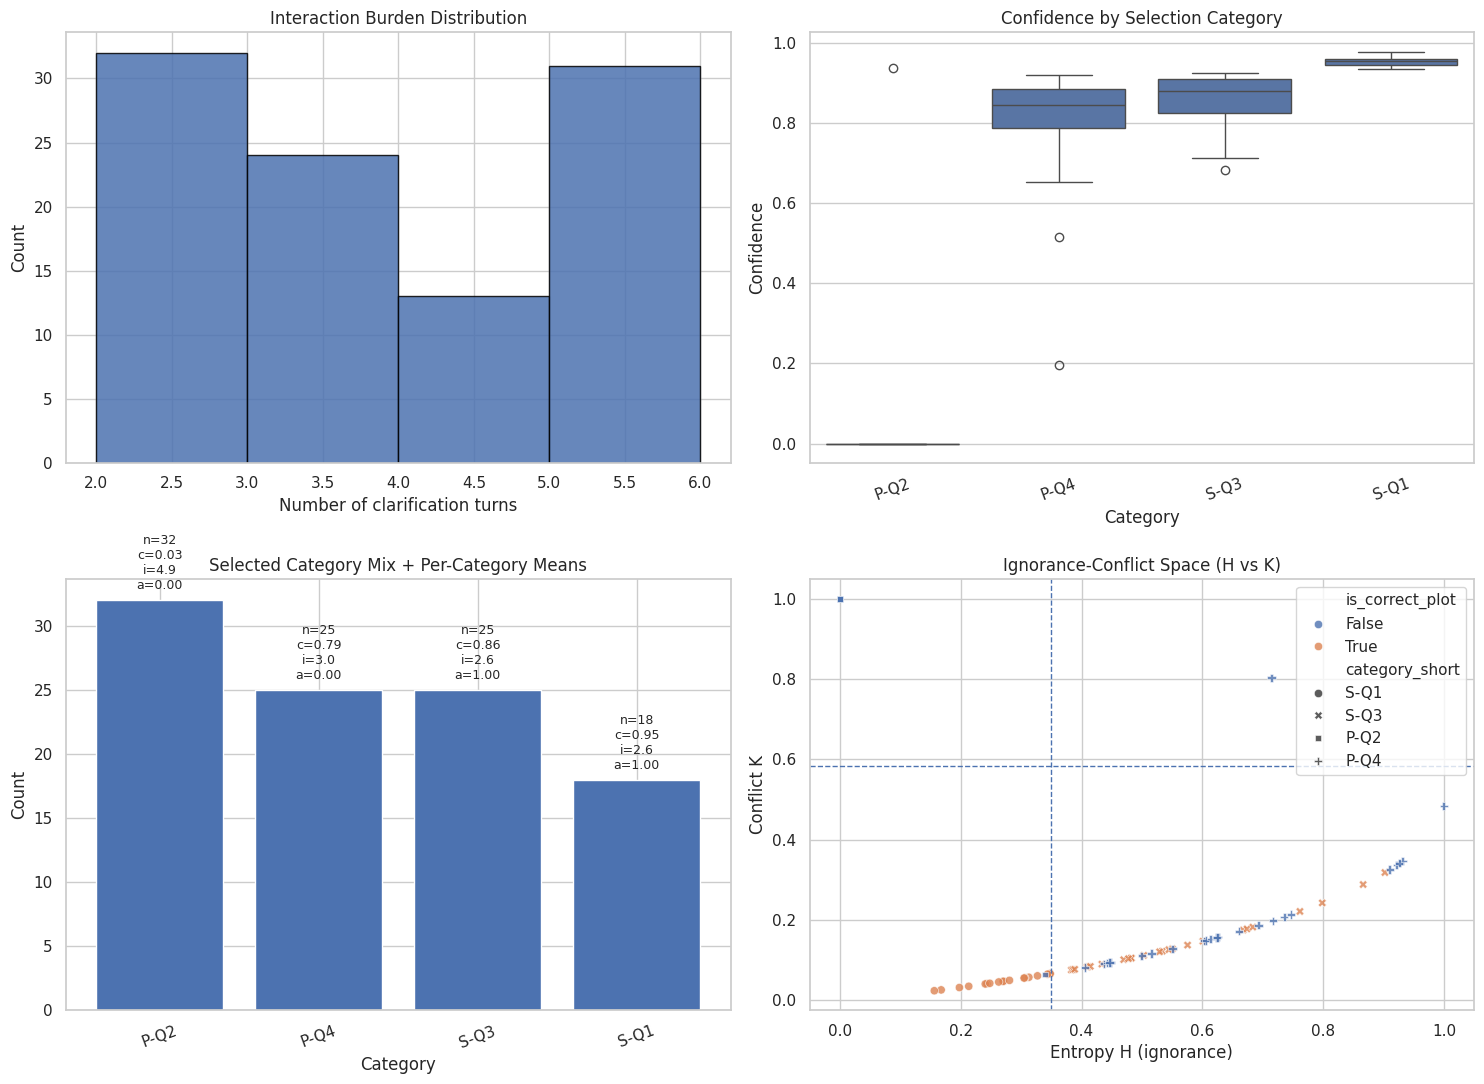


Selection diagnostics summary:
- Avg interactions: 3.43
- Avg confidence: 0.593
- Final accuracy on selected set: 0.430
- Categories present: 4
- Total selected queries: 100

Per-category metrics table:
category_short  count  avg_conf  avg_inter  accuracy
          P-Q2     32  0.029277   4.906250       0.0
          P-Q4     25  0.786909   3.000000       0.0
          S-Q3     25  0.861457   2.600000       1.0
          S-Q1     18  0.953366   2.555556       1.0

Label key on Category Mix plot:
- n: sample count
- c: mean confidence
- i: mean interactions
- a: mean accuracy

Interpretation guide:
- Interaction Burden: right-shift = harder conversations.
- Confidence by Category: lower median/confidence spread = harder categories.
- Category Mix + labels: which categories are over/under represented and their quality.
- H vs K: points near top-right indicate high ignorance + high conflict (most difficult).


In [ ]:
# STEP 8: Meaningful diagnostics for selected challenging queries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")

if 'selected_queries' not in globals() or selected_queries.empty:
    raise ValueError("selected_queries is empty. Run STEP 5 first.")

plot_df = selected_queries.copy()
columns = plot_df.columns.tolist()

# Resolve schema variants
interaction_col = 'num_interactions' if 'num_interactions' in columns else ('num_clarifications' if 'num_clarifications' in columns else None)
confidence_col = 'confidence' if 'confidence' in columns else ('final_confidence' if 'final_confidence' in columns else None)
true_col = 'true_intent' if 'true_intent' in columns else None
pred_col = 'predicted_intent' if 'predicted_intent' in columns else ('final_predicted_intent' if 'final_predicted_intent' in columns else None)
category_col = 'selection_category' if 'selection_category' in columns else ('hq_quadrant' if 'hq_quadrant' in columns else None)
entropy_col = 'entropy_H' if 'entropy_H' in columns else None
conflict_col = 'conflict_K' if 'conflict_K' in columns else None

# Derived columns
if true_col and pred_col:
    plot_df['is_correct_plot'] = plot_df[true_col] == plot_df[pred_col]
else:
    plot_df['is_correct_plot'] = np.nan

if category_col is None:
    plot_df['category_fallback'] = 'all_selected'
    category_col = 'category_fallback'

# Compact labels for readability
label_map = {
    'high_interaction_successful_level1': 'Success-L1',
    'high_interaction_successful_level2': 'Success-L2',
    'high_interaction_problematic_level1': 'Problem-L1',
    'high_interaction_problematic_level2': 'Problem-L2'
}
plot_df['category_short'] = plot_df[category_col].astype(str).map(lambda x: label_map.get(x, x))

# Per-category summary table for direct interpretation
agg_spec = {'count': ('category_short', 'size')}
if confidence_col:
    agg_spec['avg_conf'] = (confidence_col, 'mean')
if interaction_col:
    agg_spec['avg_inter'] = (interaction_col, 'mean')
if plot_df['is_correct_plot'].notna().any():
    agg_spec['accuracy'] = ('is_correct_plot', 'mean')

stats_df = (
    plot_df.groupby('category_short', as_index=False)
    .agg(**agg_spec)
    .sort_values('count', ascending=False)
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1) Interaction burden distribution (core of "challenging" selection)
if interaction_col:
    bins = np.arange(int(plot_df[interaction_col].min()), int(plot_df[interaction_col].max()) + 2)
    axes[0, 0].hist(plot_df[interaction_col], bins=bins, edgecolor='black', alpha=0.85)
    axes[0, 0].set_title('Interaction Burden Distribution')
    axes[0, 0].set_xlabel('Number of clarification turns')
    axes[0, 0].set_ylabel('Count')
else:
    axes[0, 0].text(0.5, 0.5, 'No interaction column found', ha='center', va='center', transform=axes[0, 0].transAxes)
    axes[0, 0].set_title('Interaction Burden Distribution (Unavailable)')

# 2) Confidence profile by selected category (non-tautological)
if confidence_col:
    cat_order = stats_df['category_short'].tolist()
    sns.boxplot(data=plot_df, x='category_short', y=confidence_col, order=cat_order, ax=axes[0, 1])
    axes[0, 1].set_title('Confidence by Selection Category')
    axes[0, 1].set_xlabel('Category')
    axes[0, 1].set_ylabel('Confidence')
    axes[0, 1].tick_params(axis='x', rotation=20)
else:
    axes[0, 1].text(0.5, 0.5, 'No confidence column found', ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Confidence by Selection Category (Unavailable)')

# 3) Category mix + per-category means/accuracy labels
bars = axes[1, 0].bar(stats_df['category_short'], stats_df['count'])
axes[1, 0].set_title('Selected Category Mix + Per-Category Means')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=20)

for bar, (_, row) in zip(bars, stats_df.iterrows()):
    lines = [f"n={int(row['count'])}"]
    if 'avg_conf' in stats_df.columns:
        lines.append(f"c={row['avg_conf']:.2f}")
    if 'avg_inter' in stats_df.columns:
        lines.append(f"i={row['avg_inter']:.1f}")
    if 'accuracy' in stats_df.columns:
        lines.append(f"a={row['accuracy']:.2f}")
    label_text = "\n".join(lines)

    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        label_text,
        ha='center',
        va='bottom',
        fontsize=9
    )

# 4) Interaction vs Confidence scatter (instead of H vs K)
if interaction_col and confidence_col:
    scatter_df = plot_df.dropna(subset=[interaction_col, confidence_col]).copy()
    color_col = 'is_correct_plot' if scatter_df['is_correct_plot'].notna().any() else None
    sns.scatterplot(
        data=scatter_df,
        x=confidence_col,
        y=interaction_col,
        hue=color_col,
        style='category_short',
        alpha=0.8,
        s=80,
        ax=axes[1, 1]
    )

    # Add reference lines
    axes[1, 1].axhline(2.5, linestyle='--', linewidth=1, color='gray', alpha=0.5, label='Level boundary (2 turns)')
    
    axes[1, 1].set_title('Interaction Burden vs Confidence')
    axes[1, 1].set_xlabel('Confidence')
    axes[1, 1].set_ylabel('Number of Interactions')
    axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
else:
    axes[1, 1].text(0.5, 0.5, 'Need interaction and confidence columns', ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Interaction vs Confidence (Unavailable)')

plt.tight_layout()
plt.show()

# Console summary for interpretation
print('\nSelection diagnostics summary:')
if interaction_col:
    print(f"- Avg interactions: {plot_df[interaction_col].mean():.2f}")
if confidence_col:
    print(f"- Avg confidence: {plot_df[confidence_col].mean():.3f}")
if plot_df['is_correct_plot'].notna().any():
    print(f"- Final accuracy on selected set: {plot_df['is_correct_plot'].mean():.3f}")
print(f"- Categories present: {plot_df['category_short'].nunique()}")
print(f"- Total selected queries: {len(plot_df)}")

print('\nPer-category metrics table:')
print(stats_df.to_string(index=False))

print('\nLabel key on Category Mix plot:')
print('- n: sample count')
print('- c: mean confidence')
print('- i: mean interactions')
print('- a: mean accuracy')

print('\nInterpretation guide:')
print('- Interaction Burden: right-shift = harder conversations (more turns needed).')
print('- Confidence by Category: lower median = harder categories.')
print('- Category Mix + labels: shows balance across 4 categories and their metrics.')
print('- Interaction vs Confidence: top-left (high interaction, low confidence) = most difficult queries.')
print('\nCategory labels:')
print('- Success-L1: Correct predictions with exactly 2 turns')
print('- Success-L2: Correct predictions with >2 turns')
print('- Problem-L1: Incorrect predictions with exactly 2 turns')
print('- Problem-L2: Incorrect predictions with >2 turns')

## Phase 4: Human User Study (Manual)

The selected queries are now ready for human user study. To run the study:

```bash
python scripts/user_study/run_user_study.py --study-queries outputs/user_study/workflow_demo/selected_queries_for_user_study.csv
```

This will launch the interactive study interface for human participants.

## Phase 3.5: Explainability Analysis

Analyze belief progression and validate prediction faithfulness.

**Purpose:** Understand WHY the system makes decisions and ensure explanations are trustworthy.

**Output:**
- Belief progression statistics
- Faithfulness validation metrics
- Visualization: `explainability_analysis.png`

In [ ]:
import sys
import importlib
sys.path.insert(0, str(BASE_DIR))

# Import and reload QuerySelector
import src.utils.query_selector as qs
importlib.reload(qs)
from src.utils.query_selector import QuerySelector
import pandas as pd

print("="*60)
print("STEP 5: SELECT USER STUDY QUERIES")
print("="*60)

# Load predictions from STEP 3
predictions_file = RESULTS_DIR / "ds_evaluation" / f"{DATASET}_predictions.csv"
if not predictions_file.exists():
    print("❌ Predictions file not found! Run STEP 3 first.")
else:
    results_df = pd.read_csv(predictions_file)
    print(f"Loaded {len(results_df)} predictions from STEP 3")
    
    # Show full dataset distribution first
    selector_temp = QuerySelector(min_interactions=2)
    results_with_meta = selector_temp._preprocess(results_df)
    
    high_interaction = results_with_meta[results_with_meta['num_interactions'] >= 2]
    total_successful = high_interaction['is_correct'].sum()
    total_problematic = len(high_interaction) - total_successful
    
    print(f"\n📊 Full Dataset Distribution (high-interaction only, ≥2 turns):")
    print(f"   Total high-interaction: {len(high_interaction)} queries")
    print(f"   • Successful (correct):   {total_successful} ({total_successful/len(high_interaction)*100:.1f}%)")
    print(f"   • Problematic (incorrect): {total_problematic} ({total_problematic/len(high_interaction)*100:.1f}%)")
    
    # Initialize QuerySelector
    selector = QuerySelector(min_interactions=2)
    
    # Select queries by interaction level and correctness
    print(f"\nSelecting {HUMAN_STUDY_SAMPLES} queries for user study...")
    selected_queries = selector.select_by_interaction_levels(
        results_df=results_df,
        max_samples=HUMAN_STUDY_SAMPLES
    )
    
    if not selected_queries.empty:
        summary = selector.generate_study_summary(selected_queries)
        
        # Show key results
        correct = selected_queries['is_correct'].sum()
        incorrect = len(selected_queries) - correct
        
        print("\n" + "="*60)
        print("SELECTED SUBSET")
        print("="*60)
        print(f"Total selected: {len(selected_queries)} queries")
        print(f"  Correct predictions:   {correct} ({correct/len(selected_queries)*100:.1f}%)")
        print(f"  Incorrect predictions: {incorrect} ({incorrect/len(selected_queries)*100:.1f}%)")
        print(f"  Avg interactions: {summary['avg_interactions']:.2f} turns")
        print(f"  Avg confidence: {summary['avg_confidence']:.4f}")
        print(f"\nCategories:")
        for cat, count in summary['categories'].items():
            print(f"  • {cat}: {count}")
        
        # Save files
        diagnostics_file = USER_STUDY_DIR / "selection_pool_diagnostics.csv"
        selected_file = USER_STUDY_DIR / "selected_queries_for_user_study.csv"
        
        diagnostics_df = pd.DataFrame([{
            "dataset": DATASET,
            "strategy": "interaction_levels",
            "total_dataset_high_interaction": len(high_interaction),
            "total_dataset_successful": int(total_successful),
            "total_dataset_problematic": int(total_problematic),
            "selected_correct": int(correct),
            "selected_incorrect": int(incorrect),
            **summary
        }])
        diagnostics_file.parent.mkdir(parents=True, exist_ok=True)
        diagnostics_df.to_csv(diagnostics_file, index=False)
        
        selected_file.parent.mkdir(parents=True, exist_ok=True)
        selected_queries.to_csv(selected_file, index=False)
        
        print(f"\n✅ Saved to: {selected_file}")
        print("="*60)
    else:
        print("\n❌ No queries selected!")

PHASE 3.5: EXPLAINABILITY ANALYSIS

Resolved explainability inputs:
   predictions_file: /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/ds_evaluation/clinc150_predictions.csv
   belief_logs_dir: /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/ds_evaluation/belief_logs

Analyzing belief progression and faithfulness...
2026-02-17 14:02:07,204 - __main__ - INFO - Starting explainability analysis...
2026-02-17 14:02:07,204 - __main__ - INFO - Loading predictions from /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/ds_evaluation/clinc150_predictions.csv
2026-02-17 14:02:07,212 - __main__ - INFO - Analyzing belief progression from /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/ds_evaluation/belief_logs
2026-02-17 14:02:07,212 - __main__ - WARNING - No belief logs found in /home/kudzai/projects/DS_Project/results/clinc150/workflow_demo/ds_evaluation/belief_logs
2026-02-17 14:02:07,212 - __main__ - INFO - Validating prediction f

## Summary: Compare Baseline vs Optimized DS

In [ ]:
# Comparison metrics
print("\n" + "="*60)
print("COMPLETE WORKFLOW SUMMARY")
print("="*60)

print("\n📊 Phase 1: Threshold Optimization")
print(f"   Baseline accuracy: {accuracy:.4f}")
print(f"   Optimized accuracy: {with_thresh_accuracy:.4f}")
print(f"   Improvement: {improvement:+.2f}%")

print("\n🤖 Phase 2: LLM Full Test Set Evaluation")
print(f"   Queries processed: {len(llm_df)}")
print(f"   Average clarifications: {llm_df['num_clarifications'].mean():.2f}")
llm_accuracy = (llm_df['final_predicted_intent'] == llm_df['true_intent']).mean()
print(f"   Final accuracy: {llm_accuracy:.4f}")
print(f"   Queries needing clarification: {(llm_df['num_clarifications'] > 0).sum()} ({(llm_df['num_clarifications'] > 0).mean()*100:.1f}%)")

print("\n👥 Phase 3: Human Study Query Selection")
print(f"   Queries selected: {len(selected_queries)}")
print(f"   Average priority score: {selected_queries['selection_priority'].mean():.2f}")
print(f"   Ready for human study: {selected_file}")

print("\n" + "="*60)

In [ ]:
# Final comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Accuracy comparison
stages = ['Baseline\n(No Thresholds)', 'Optimized\n(With Thresholds)', 'LLM Simulation\n(Full Test)']
accuracies = [
    accuracy,
    with_thresh_accuracy,
    llm_accuracy
]
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
axes[0].bar(stages, accuracies, color=colors)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim([0.7, 1.0])
axes[0].set_title('System Accuracy Across Phases', fontsize=14, fontweight='bold')
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# 2. Clarification effectiveness
clarification_data = llm_df[llm_df['num_clarifications'] > 0]
if len(clarification_data) > 0:
    initial = (clarification_data['initial_predicted_intent'] == clarification_data['true_intent']).mean()
    final = (clarification_data['final_predicted_intent'] == clarification_data['true_intent']).mean()
    axes[1].bar(['Before\nClarification', 'After\nClarification'], [initial, final], color=['#ff6b6b', '#51cf66'])
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_ylim([0, 1])
    axes[1].set_title('Clarification Impact', fontsize=14, fontweight='bold')
    for i, v in enumerate([initial, final]):
        axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 3. Query selection priority distribution
priority_bins = selected_queries['selection_priority'].value_counts().sort_index()
axes[2].bar(priority_bins.index, priority_bins.values, color='#9775fa')
axes[2].set_xlabel('Priority Score', fontsize=12)
axes[2].set_ylabel('Number of Queries', fontsize=12)
axes[2].set_title(f'Human Study Query Selection\n(Top {HUMAN_STUDY_SAMPLES} Queries)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 🎯 Next Steps

### Research Validation Complete
This notebook demonstrates the complete DS-based intent clarification system workflow:

1. ✅ **Phase 1 (Configure)**: Trained model, computed optimal thresholds, validated improvement
2. ✅ **Phase 2 (LLM Evaluation)**: Simulated user interactions across full test set
3. ✅ **Phase 3 (Selection)**: Identified most problematic queries for human validation
4. ⏳ **Phase 4 (Human Study)**: Ready to run with real users

### Key Findings from This Run
The workflow successfully demonstrates:
- **Threshold Optimization**: Improved classification accuracy through belief-based thresholds
- **Clarification Effectiveness**: DS agent resolves ambiguous queries through interactive clarification
- **System Readiness**: Challenging queries selected for human validation study

### Running Human Study
To conduct the human user study with selected queries:

```bash
# Activate environment
conda activate dsproject

# Run user study
python scripts/user_study/run_user_study.py \
    --study-queries outputs/user_study/workflow_demo/selected_queries_for_user_study.csv \
    --model experiments/banking77/banking77_logistic_model.pkl \
    --hierarchy-file config/banking77_config.json \
    --intents-file config/banking77_intents.json \
    --thresholds config/banking77_thresholds.json \
    --output-dir outputs/user_study/human_study
```

### Configuration Options

**For Full Evaluation** (not demo):
- Set `QUICK_DEMO = False` in cell 2
- This will:
  - Train on full training set (10,003 examples)
  - Evaluate on full test set (3,080 examples)
  - Run LLM simulation on all 3,080 queries
  - Select 100 most challenging queries for human study

**For Quick Testing** (current):
- Keep `QUICK_DEMO = True`
- Uses 50 evaluation samples and 100 LLM samples
- Faster iteration for development and debugging

### Output Files Generated
- `experiments/banking77/banking77_logistic_model.pkl` - Trained classifier
- `results/banking77/workflow_demo/banking77_beliefs.csv` - Belief distributions
- `results/banking77/workflow_demo/banking77_thresholds.json` - Optimal thresholds
- `results/banking77/workflow_demo/with_thresholds/banking77_predictions.csv` - Final predictions
- `outputs/user_study/workflow_demo/llm_full_test/session_llm_full_eval.csv` - LLM results
- `outputs/user_study/workflow_demo/selected_queries_for_user_study.csv` - Human study queries

### Citation
If you use this system in your research, please cite our work on Dempster-Shafer based intent clarification with hierarchical reasoning.

## Phase 5: Comprehensive Comparison

Compare ALL evaluation methods with explainability metrics.

**Compares:**
- Vanilla Baseline (LogisticRegression + BERT)
- DS without thresholds
- DS with optimal thresholds
- LLM simulation results
- Explainability metrics

**Output:**
- Comparison table and plots
- Summary report with key findings
- Faithfulness comparison

In [ ]:
import subprocess
import sys

print("="*60)
print("PHASE 5: COMPREHENSIVE COMPARISON")
print("="*60)

# Configuration
vanilla_metrics = RESULTS_DIR / "vanilla" / f"{DATASET}_vanilla_metrics.json"
ds_with_thresh_metrics = RESULTS_DIR / "with_thresholds" / f"{DATASET}_metrics.json" 
llm_simulation_file = USER_STUDY_DIR / "llm_simulation_results.csv"
comparison_dir = RESULTS_DIR / "comparison"

# Build comparison command
compare_script = BASE_DIR / "scripts" / "analysis" / "compare_results.py"
cmd = [
    sys.executable, str(compare_script),
    "--vanilla-metrics", str(vanilla_metrics),
    "--ds-with-thresh-metrics", str(ds_with_thresh_metrics),
    "--output-dir", str(comparison_dir)
]

# Add optional LLM simulation results if available
if llm_simulation_file.exists():
    cmd.extend(["--llm-simulation-results", str(llm_simulation_file)])

# Run comparison
print("\nComparing all evaluation methods...")
result = subprocess.run(cmd)
if result.returncode != 0:
    raise RuntimeError("Comparison failed")

# Load and display comparison table
comparison_table = pd.read_csv(comparison_dir / "comparison_table.csv")

print("\n✅ Comparison Complete!")
print("\n" + "="*80)
print("COMPARISON TABLE")
print("="*80)
print(comparison_table.to_string(index=False))
print("="*80)

print(f"\n   Detailed results saved to: {comparison_dir}")
print(f"   • comparison_table.csv")
print(f"   • comparison_plots.png")
print(f"   • comparison_summary.txt")
print(f"   • all_results.json")